<a href="https://colab.research.google.com/github/asurovi/Composite_Delmination_Undergrad_Thesis/blob/main/4PM_Hackaton3_VAE_EELS_AgnilaGhoshSurovi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#4th School on ML/AI for Electron Microscopy. Hackaton #3.

# EELS spectra analysis by Variational Autoencoder

*The EELS datasets of indium-tin oxide cubes aquired and provided by Kevin Roccapriore*

**Please activate GPU acceleration in Colab before running this notebook.**



> Runtime → Change runtime type → Hardware accelerator → GPU, then click Save





### 1. Import the datasets

Download EELS data. This is 12 EELS spectral data sets of **indium-tin oxide** cubes aquired by **Kevin Roccapriore**, measured at different resolutions and geometries. Start with the one you like!

In [ ]:
from copy import deepcopy as dc

import numpy as np
from sklearn import decomposition

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.cluster import KMeans

In [ ]:
%%capture
!wget https://www.dropbox.com/s/nicyvttpihzh1cd/Plasmonic_sets_7222021_fixed.npy
loadedfile = np.load("Plasmonic_sets_7222021_fixed.npy", allow_pickle=True).tolist()

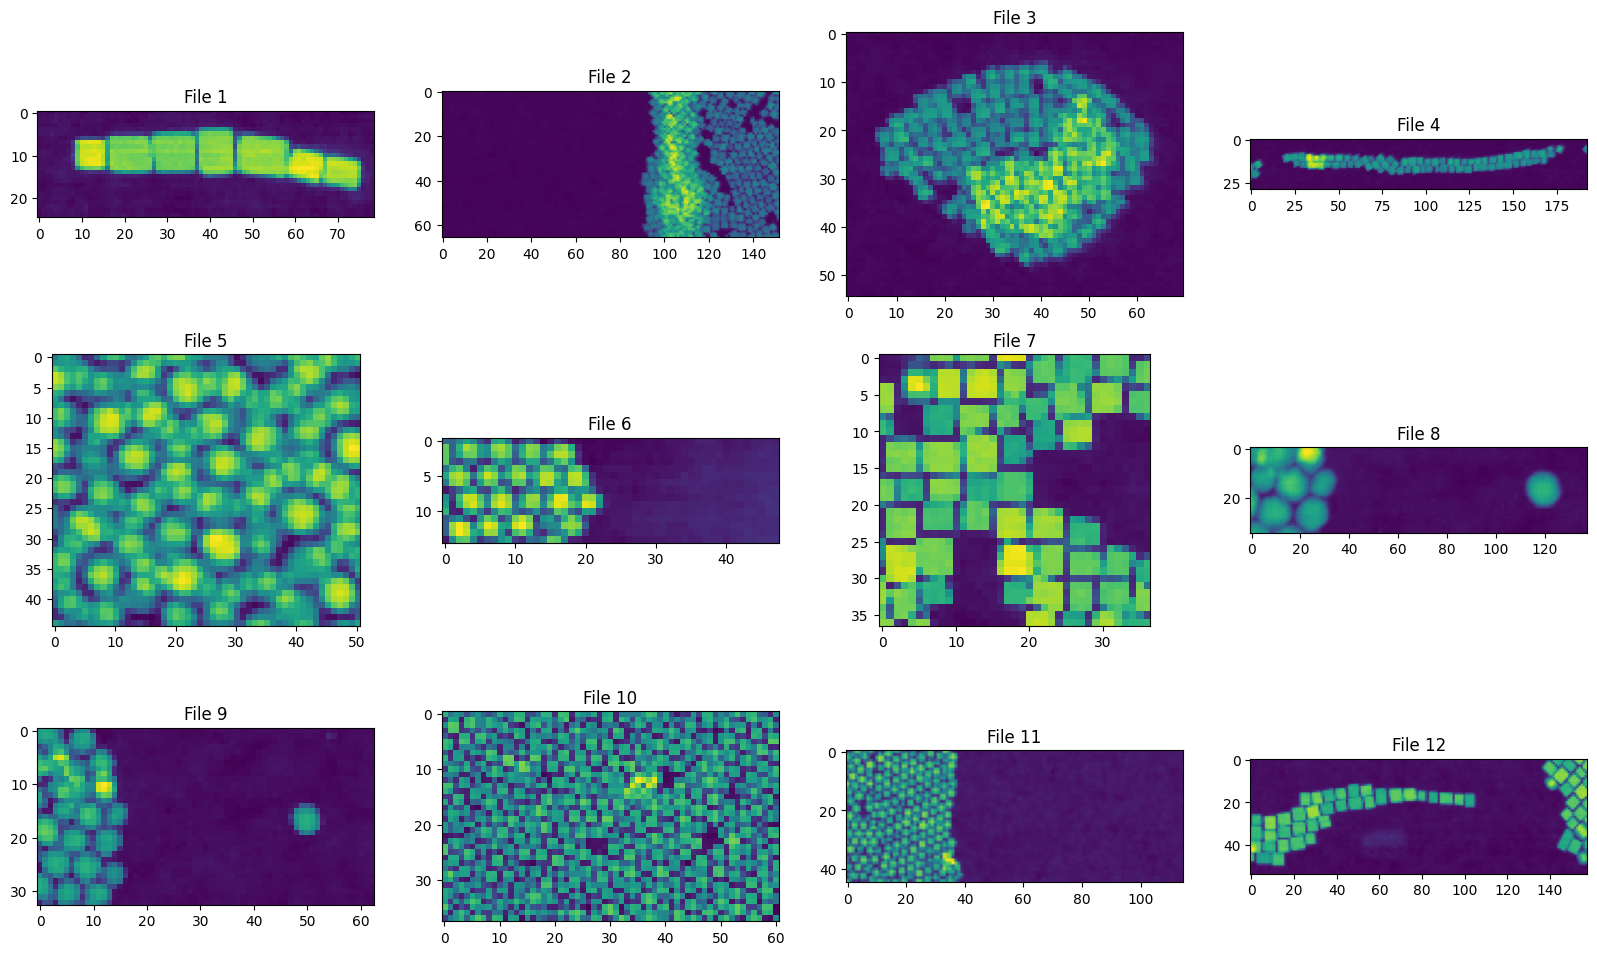

In [ ]:
num_im = len(loadedfile)
rows = int(np.ceil(float(num_im)/4))
cols = int(np.ceil(float(num_im)/rows))

gs = gridspec.GridSpec(rows, cols)
fig = plt.figure(figsize = (5*cols, 3*(1+rows)))

for kk in range(num_im):
    ax = fig.add_subplot(gs[kk])
    fileset  = loadedfile['{}'.format(kk+1)]
    f1,f2,f3,f4 = fileset
    img, data, e_ax, img_scale = fileset[f1], fileset[f2], fileset[f3], fileset[f4]
    ax.imshow(img)
    ax.set_title("File {}".format(kk+1))

In [ ]:
# Choose the dataset for analysis
k = 12

img = loadedfile['{}'.format(k)]['image']
specim = loadedfile['{}'.format(k)]['spectrum image']
e_ax = loadedfile['{}'.format(k)]['energy axis']
imscale = loadedfile['{}'.format(k)]['scale']

In [ ]:
# Read grid spectoscopy data
hdata = specim
hdata = hdata.astype(np.float64)

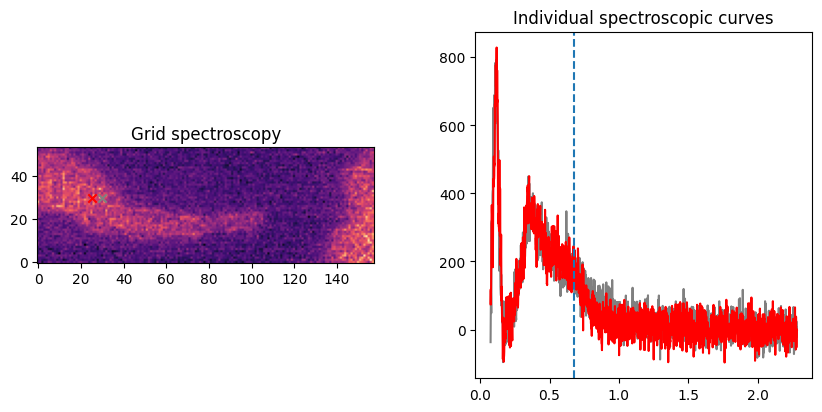

In [ ]:
# Select a slice and points for extracting idividual spectoscopic curves
# For convenience, we look at the data in pixels (however, we store the real scale as e_ax)

s = 480 # slice
pos1 = [30, 30]
pos2 = [25, 30]

# Plot
_, ax = plt.subplots(1, 2, figsize=(10, 4.5))
ax[0].imshow(hdata[..., s], cmap='magma', origin="lower")
ax[0].scatter(pos1[0], pos1[1], c='gray', marker='x')
ax[1].plot(e_ax, hdata[pos1[1], pos1[0], :], c='gray')
ax[0].scatter(pos2[0], pos2[1], c='red', marker='x')
ax[1].plot(e_ax, hdata[pos2[1], pos2[0], :], c='red')
ax[1].axvline(x=e_ax[s], linestyle = '--')
ax[0].set_title('Grid spectroscopy')
ax[1].set_title('Individual spectroscopic curves')
plt.subplots_adjust(wspace=.3)

## 2. Unsupervised clustering of EELS spectra

Let start with basic unsupervised clustering methods to identify groups of spectra with similar features. Start with **K-means** clustering and **Gaussian mixture models**, and vary the number of clusters to determine which partition gives the most physically meaningful separation of the data.

You may also explore additional clustering approaches.

Reference: https://scikit-learn.org/stable/modules/clustering.html

### K-mean

In [ ]:
#EELS spectra normalization
X_vec = hdata.copy()
d1, d2, d3 = X_vec.shape
X_vec = X_vec.reshape(d1*d2, d3)
X_vec = (X_vec - np.min(X_vec)) / np.ptp(X_vec)

In [ ]:
## import library
n_clusters = 6 #choose number of clusters

km = KMeans(n_clusters)
km_results = km.fit(np.array(X_vec)) #we can intelligently fold the data and perform Kmeans

#Get the cluster centers and the labels
km_labels = km_results.labels_
km_centers = km_results.cluster_centers_

#Reshape the labels
km_labels = km_labels.reshape(d1, d2)

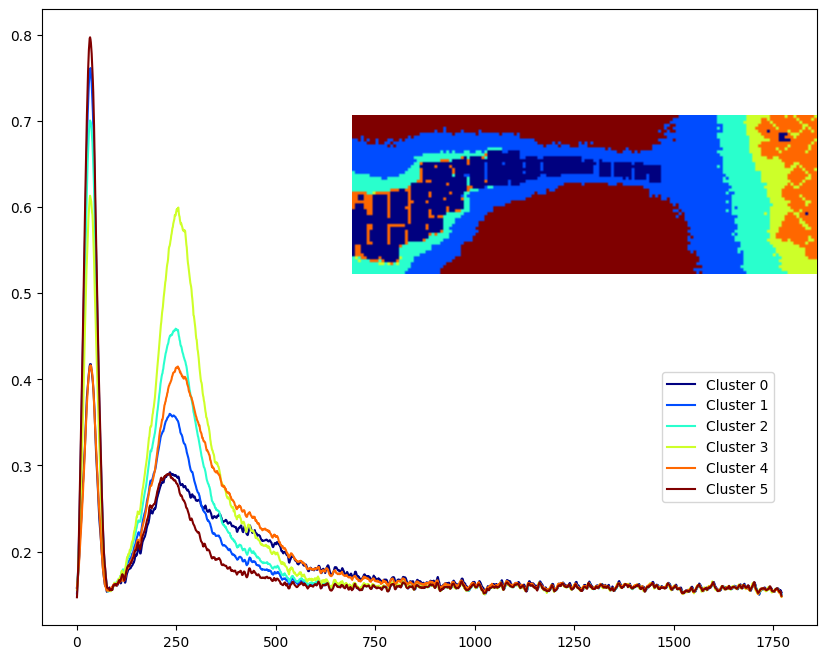

In [ ]:
# Set the color map to match the number of clusters
colors = plt.cm.jet(np.linspace(0, 1, n_clusters))

plt.figure(figsize=(10, 8))
labels = []

for ind, color in zip(np.arange(n_clusters), colors):
    plt.plot(km_centers[ind, :], color=color)
    labels.append(f"Cluster {ind}")

plt.legend(labels, loc=(0.8, 0.2))

# Create inset for image
ax = plt.gca()
axins = ax.inset_axes([0.4, 0.4, 0.6, 0.6])

# Use the same color map for the inset image
# Normalize the values to match the number of clusters
norm = mpl.colors.Normalize(vmin=km_labels.min(), vmax=km_labels.max())
im2_colored = plt.cm.jet(norm(km_labels))
axins.imshow(im2_colored)
axins.axis('off')

plt.show()

### Gaussian mixture modeling


In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=6,covariance_type="diag") #choose number of components

gmm_results = gmm.fit(np.array(X_vec)) #we can intelligently fold the data and perform GM
gmm_labels = gmm_results.fit_predict(X_vec)
gmm_means = gmm_results.means_

/tmp/ipykernel_865/423261048.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet', gmm.n_components)


Text(0, 0.5, 'GMM Label')

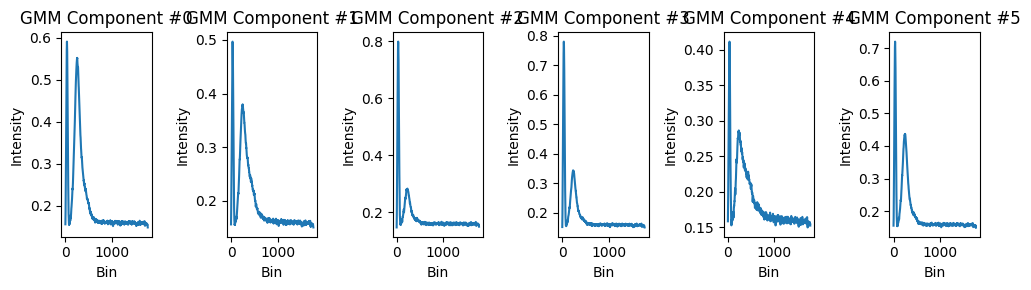

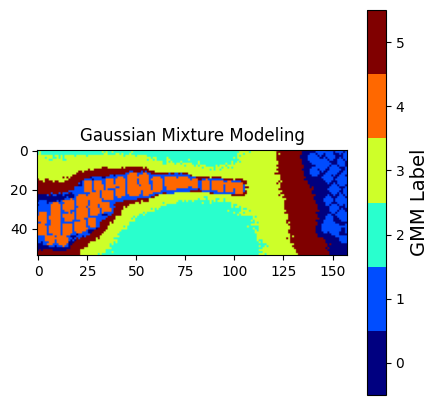

In [ ]:
gmm_labels= gmm_labels.reshape(d1, d2)

#Plot the GMM means
fig, axes = plt.subplots(nrows=1, ncols=gmm.n_components, figsize = (10,3))
for ind, ax in enumerate(axes.flat):
    ax.plot(gmm_means[ind,:])
    ax.set_title('GMM Component #' + str(ind))
    ax.set_ylabel("Intensity")
    ax.set_xlabel("Bin")
fig.tight_layout()

#Plot the labels
cmap = plt.cm.get_cmap('jet', gmm.n_components)

#Plot the cluster labels
fig, axes = plt.subplots(figsize=(5,5))
im = axes.imshow(gmm_labels, cmap=cmap,vmin=np.min(gmm_labels) - 0.5,
                      vmax=np.max(gmm_labels) + 0.5)
axes.set_title('Gaussian Mixture Modeling')
cbar = fig.colorbar(im, ax=axes)
cbar.ax.set_yticks(np.arange(np.min(gmm_labels), np.max(gmm_labels) + 1))
cbar.ax.set_ylabel("GMM Label", fontsize = 14)

## 3. Setup for VAE analysis

Below is the basic code for setting up a simple VAE model. Please, go through this section to get a general understanding of how such a model is organized and how the main components are connected.

In [ ]:
#@title manifold visualizing

def plot_vae_manifold(
    vae,
    device,
    latent_dim=2,
    active_dims=(0, 1),
    z_ref=None,
    grid_size=8,
    padding=0.15,
    energy_axis=None,
    figsize=(12, 12)
):
    """
    Visualize a VAE manifold as a grid of decoded spectra.

    Parameters
    ----------
    vae : trained VAE model
    device : torch.device
    latent_dim : int
        Full latent dimensionality of the model.
    active_dims : tuple(int, int)
        Which two latent dimensions to vary.
    z_ref : np.ndarray or None
        Optional encoded latent means, shape (N, latent_dim).
        If given, plotting ranges are chosen from these data.
        If None, range [-2, 2] is used.
    grid_size : int
        Number of points along each latent axis.
    padding : float
        Small extra range around min/max when z_ref is provided.
    energy_axis : np.ndarray or None
        Optional x-axis for spectra. If None, channel index is used.
    figsize : tuple
        Figure size.
    """

    vae.eval()

    d0, d1 = active_dims

    if z_ref is not None:
        zmin0, zmax0 = z_ref[:, d0].min(), z_ref[:, d0].max()
        zmin1, zmax1 = z_ref[:, d1].min(), z_ref[:, d1].max()

        dz0 = zmax0 - zmin0
        dz1 = zmax1 - zmin1

        zmin0 -= padding * dz0
        zmax0 += padding * dz0
        zmin1 -= padding * dz1
        zmax1 += padding * dz1
    else:
        zmin0, zmax0 = -2.0, 2.0
        zmin1, zmax1 = -2.0, 2.0

    grid_x = np.linspace(zmin0, zmax0, grid_size)
    grid_y = np.linspace(zmin1, zmax1, grid_size)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize, squeeze=False)

    with torch.no_grad():
        for i, y in enumerate(grid_y[::-1]):   # reverse for intuitive orientation
            for j, x in enumerate(grid_x):
                z = np.zeros((1, latent_dim), dtype=np.float32)
                z[0, d0] = x
                z[0, d1] = y

                z_tensor = torch.tensor(z, dtype=torch.float32).to(device)
                spectrum = vae.decode(z_tensor).cpu().numpy()[0]

                ax = axes[i, j]

                if energy_axis is None:
                    ax.plot(spectrum, lw=1)
                else:
                    ax.plot(energy_axis, spectrum, lw=1)

                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_xlim(0, len(spectrum) - 1 if energy_axis is None else (energy_axis.min(), energy_axis.max())[1])

    fig.suptitle(
        f"VAE manifold: latent dims {d0} and {d1}",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# Install / import PyTorch
import torch
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
# Prepare EELS spectra for VAE

X = X_vec.astype(np.float32)

# Optional: per-spectrum normalization.
# This is often useful for EELS because intensity can vary strongly.
X = X / (X.max(axis=1, keepdims=True) + 1e-8)

X_tensor = torch.tensor(X, dtype=torch.float32)

dataset = TensorDataset(X_tensor)
batch_size = 128 #batch size for the data loader
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

input_dim = X.shape[1]   # number of energy channels


print("Input shape:", X.shape)

Input shape: (8532, 1772)


In [ ]:
# Simple fully-connected VAE for 1D EELS spectra

class SpectraVAE(torch.nn.Module):
    def __init__(self, input_dim, latent_dim=2, hidden_dim=256):
        super().__init__()

        # Encoder
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.ReLU(),
        )

        self.fc_mu = torch.nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = torch.nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim // 2, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim),
            torch.nn.Sigmoid(),   # because spectra are normalized to [0, 1]
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z)
        return x_rec, mu, logvar

In [ ]:
# VAE loss

def vae_loss(x_rec, x, mu, logvar, beta=1e-3):
    recon_loss = torch.nn.functional.mse_loss(x_rec, x, reduction="mean")

    # KL divergence between q(z|x) and N(0, I)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    loss = recon_loss + beta * kl_loss
    return loss, recon_loss, kl_loss

## 4. VAE training by Agnila

Train the VAE model and explore how its behavior changes with different hyperparameters.

Try varying the number of **training epochs**, **hidden-layer dimension**, **learning rate**, and the value of **β**, which controls the weight of the KL-divergence term in the loss function.

Compare the reconstruction quality, latent-space structure, and training-loss behavior for different parameter choices.

**Hint:** You may use ChatGPT or other LLM tools for coding assistance, as long as you can clearly and explicitly formulate what you want to accomplish.

In [ ]:
# Train VAE
LATENT_DIM = 4
HIDDEN_DIM = 256

n_epochs = 200 #number of epoch
beta = 3e-3 #KL coeffitient. The loss = reconstruction_loss + beta*KL_loss

learning_rate = 1e-3


vae = SpectraVAE(
    input_dim=input_dim,
    latent_dim=LATENT_DIM,
    hidden_dim=HIDDEN_DIM #hidden layer size
).to(device)

optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate) #learning rate

history = {
    "loss": [],
    "recon": [],
    "kl": []
}

vae.train()

for epoch in range(n_epochs):
    epoch_loss = 0
    epoch_recon = 0
    epoch_kl = 0

    for batch in loader:
        x_batch = batch[0].to(device)

        optimizer.zero_grad()

        x_rec, mu, logvar = vae(x_batch)
        loss, recon_loss, kl_loss = vae_loss(
            x_rec, x_batch, mu, logvar, beta=beta
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    epoch_loss /= len(loader)
    epoch_recon /= len(loader)
    epoch_kl /= len(loader)

    history["loss"].append(epoch_loss)
    history["recon"].append(epoch_recon)
    history["kl"].append(epoch_kl)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {epoch_loss:.5f} | "
            f"Recon: {epoch_recon:.5f} | "
            f"KL: {epoch_kl:.5f}"
        )

Epoch 000 | Loss: 0.01573 | Recon: 0.01501 | KL: 0.24060
Epoch 010 | Loss: 0.00240 | Recon: 0.00146 | KL: 0.31588
Epoch 020 | Loss: 0.00228 | Recon: 0.00132 | KL: 0.31917
Epoch 030 | Loss: 0.00220 | Recon: 0.00117 | KL: 0.34479
Epoch 040 | Loss: 0.00220 | Recon: 0.00114 | KL: 0.35395
Epoch 050 | Loss: 0.00220 | Recon: 0.00113 | KL: 0.35494
Epoch 060 | Loss: 0.00216 | Recon: 0.00111 | KL: 0.35155
Epoch 070 | Loss: 0.00216 | Recon: 0.00110 | KL: 0.35451
Epoch 080 | Loss: 0.00214 | Recon: 0.00109 | KL: 0.35104
Epoch 090 | Loss: 0.00214 | Recon: 0.00109 | KL: 0.35006
Epoch 100 | Loss: 0.00215 | Recon: 0.00110 | KL: 0.35213
Epoch 110 | Loss: 0.00216 | Recon: 0.00109 | KL: 0.35401
Epoch 120 | Loss: 0.00213 | Recon: 0.00110 | KL: 0.34581
Epoch 130 | Loss: 0.00213 | Recon: 0.00108 | KL: 0.34842
Epoch 140 | Loss: 0.00214 | Recon: 0.00108 | KL: 0.35225
Epoch 150 | Loss: 0.00213 | Recon: 0.00108 | KL: 0.35200
Epoch 160 | Loss: 0.00213 | Recon: 0.00107 | KL: 0.35497
Epoch 170 | Loss: 0.00214 | Rec

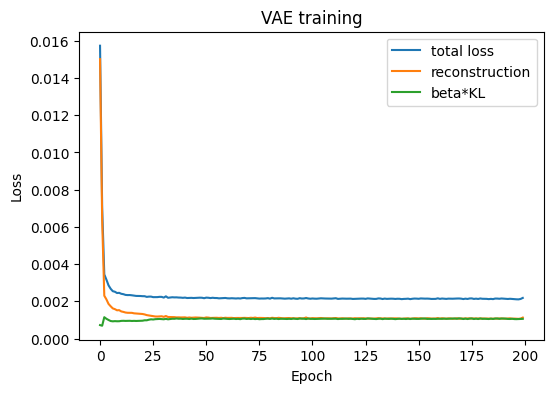

In [ ]:
# Plot training curve

plt.figure(figsize=(6, 4))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon"], label="reconstruction")
plt.plot(np.array(history["kl"])*beta, label="beta*KL")
#plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE training")
plt.show()

In [ ]:
# Extract latent coordinates for every spectrum

vae.eval()

with torch.no_grad():
    X_all = torch.tensor(X, dtype=torch.float32).to(device)
    mu, logvar = vae.encode(X_all)

    z_mean = mu.cpu().numpy()
    z_std = torch.exp(0.5 * logvar).cpu().numpy()

print("Latent shape:", z_mean.shape)

Latent shape: (8532, 4)


Using the default parameters, one of the latent dimensions collapses, indicating that the model mainly uses only one latent variable to represent the spectral variability.

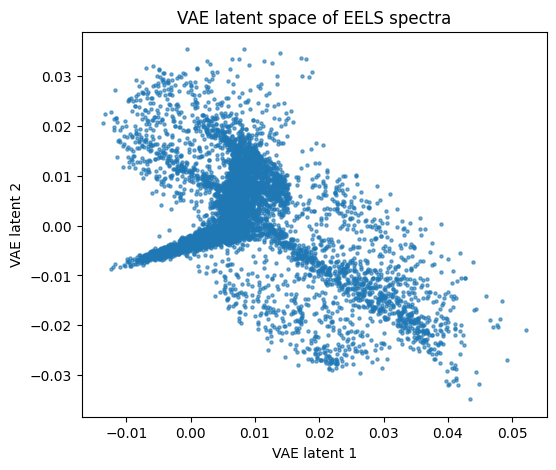

In [ ]:
# Plot 2D latent space

plt.figure(figsize=(6, 5))
plt.scatter(z_mean[:, 0], z_mean[:, 1], s=5, alpha=0.6)
plt.xlabel("VAE latent 1")
plt.ylabel("VAE latent 2")
plt.title("VAE latent space of EELS spectra")
plt.show()

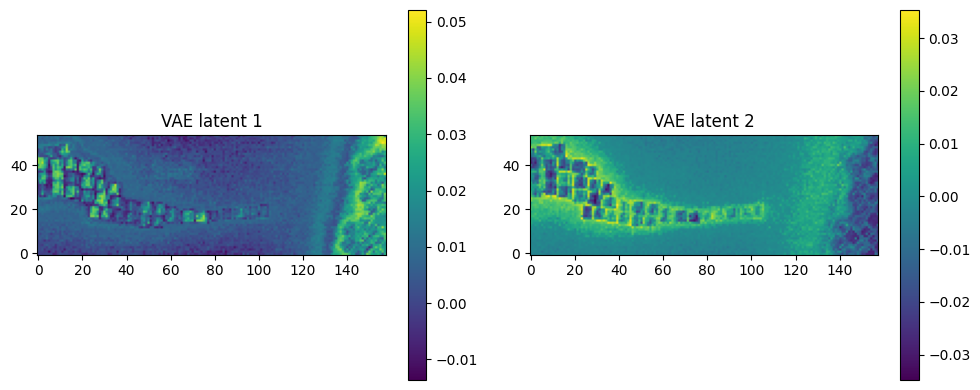

In [ ]:
# Reshape latent variables back into image form

z1_map = z_mean[:, 0].reshape(d1, d2)
z2_map = z_mean[:, 1].reshape(d1, d2)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im0 = ax[0].imshow(z1_map, origin="lower", cmap="viridis")
ax[0].set_title("VAE latent 1")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(z2_map, origin="lower", cmap="viridis")
ax[1].set_title("VAE latent 2")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

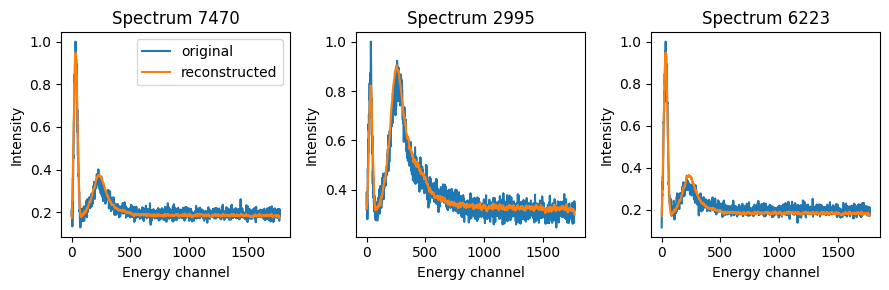

In [ ]:
# Compare original and reconstructed spectra

vae.eval()

n_examples = 3
idx = np.random.choice(X.shape[0], n_examples, replace=False)

with torch.no_grad():
    x_sample = torch.tensor(X[idx], dtype=torch.float32).to(device)
    x_rec, _, _ = vae(x_sample)
    x_rec = x_rec.cpu().numpy()

fig, axes = plt.subplots(1, n_examples, figsize=(3*n_examples, 3))

for i, ax in enumerate(axes):
    ax.plot(X[idx[i]], label="original")
    ax.plot(x_rec[i], label="reconstructed")
    ax.set_title(f"Spectrum {idx[i]}")
    ax.set_xlabel("Energy channel")
    ax.set_ylabel("Intensity")

axes[0].legend()
plt.tight_layout()
plt.show()

## 5. Cross dataset generalization by Agnila

1) Train the VAE using one selected dataset only.
2) Apply the trained model to another dataset without retraining. Do not forget to normalize the second dataset in the same way as the training dataset.
3) Compare the reconstruction error for:
 - spectra from the training dataset
 - spectra from the test dataset.
4) Visualize representative original and reconstructed spectra from both datasets.
5) Compare the latent-space distributions of the training and test datasets.

**Key question:** weather the model captures general ITO plasmon behavior or mainly learns dataset-specific geometry/resolution effects.

In [ ]:
train_min = np.min(X_vec)
train_ptp = np.ptp(X_vec)

X_vec = (X_vec - train_min) / (train_ptp + 1e-8)

In [ ]:
# 5. Cross dataset generalization

# Choose a different dataset for testing
k_test = 1   # try another dataset, but not the training k

img_test = loadedfile[str(k_test)]["image"]
specim_test = loadedfile[str(k_test)]["spectrum image"]
e_ax_test = loadedfile[str(k_test)]["energy axis"]

hdata_test = specim_test.astype(np.float64)
td1, td2, td3 = hdata_test.shape

X_test_raw = hdata_test.reshape(td1 * td2, td3)

# Interpolate test spectra onto the TRAINING energy axis
X_test_interp = np.zeros((X_test_raw.shape[0], len(e_ax)))

for i in range(X_test_raw.shape[0]):
    X_test_interp[i] = np.interp(e_ax, e_ax_test, X_test_raw[i])

# Normalize test data using same global normalization style
X_test_vec = (X_test_interp - train_min) / (train_ptp + 1e-8)

# Same per-spectrum normalization used before VAE training
X_test = X_test_vec.astype(np.float32)
X_test = X_test / (X_test.max(axis=1, keepdims=True) + 1e-8)

print("Training data:", X.shape)
print("Test data before interpolation:", X_test_raw.shape)
print("Test data after interpolation:", X_test.shape)

Training data: (8532, 1772)
Test data before interpolation: (1975, 3661)
Test data after interpolation: (1975, 1772)


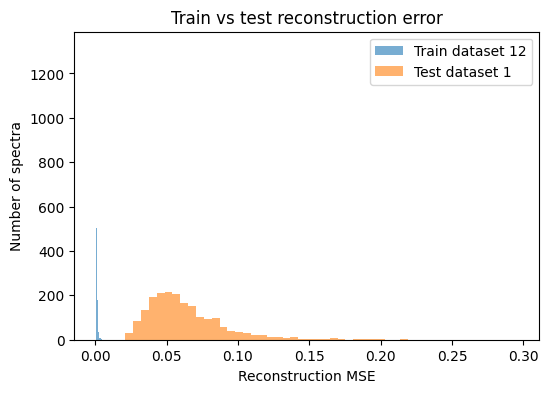

Train mean MSE: 0.0009244106
Test mean MSE: 0.06414341


In [ ]:
vae.eval()

with torch.no_grad():
    # Training reconstruction
    X_train_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    z_train, _ = vae.encode(X_train_tensor)
    X_train_rec = vae.decode(z_train).cpu().numpy()

    # Test reconstruction
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    z_test, _ = vae.encode(X_test_tensor)
    X_test_rec = vae.decode(z_test).cpu().numpy()

train_mse = np.mean((X - X_train_rec) ** 2, axis=1)
test_mse = np.mean((X_test - X_test_rec) ** 2, axis=1)

plt.figure(figsize=(6, 4))
plt.hist(train_mse, bins=50, alpha=0.6, label=f"Train dataset {k}")
plt.hist(test_mse, bins=50, alpha=0.6, label=f"Test dataset {k_test}")
plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of spectra")
plt.legend()
plt.title("Train vs test reconstruction error")
plt.show()

print("Train mean MSE:", train_mse.mean())
print("Test mean MSE:", test_mse.mean())

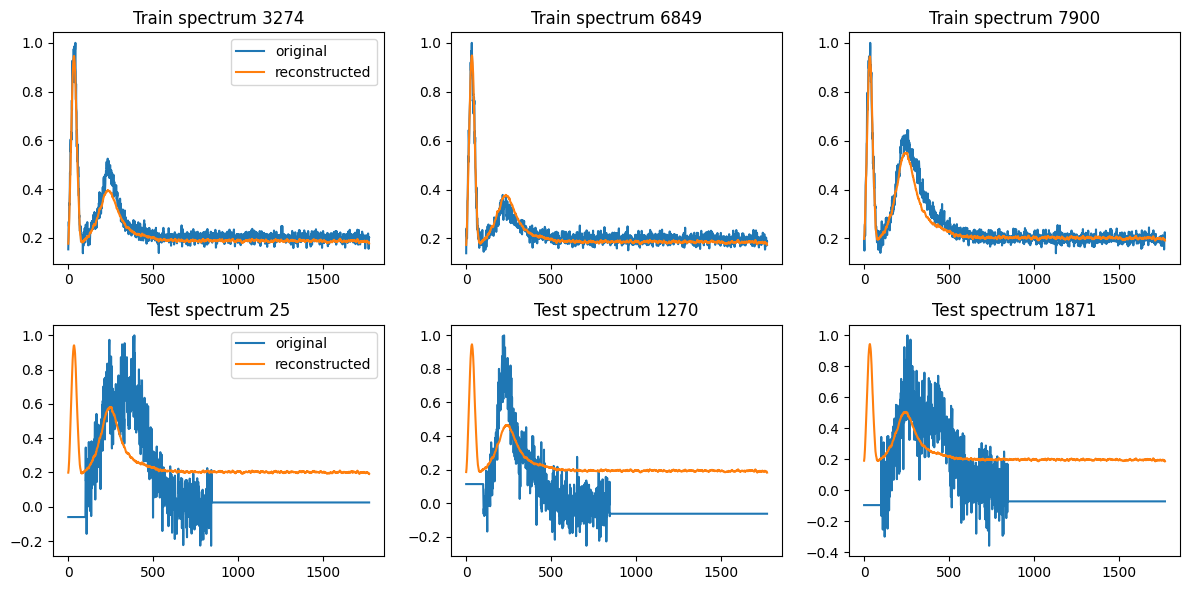

In [ ]:
n_examples = 3

train_idx = np.random.choice(X.shape[0], n_examples, replace=False)
test_idx = np.random.choice(X_test.shape[0], n_examples, replace=False)

fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 6))

for i in range(n_examples):
    axes[0, i].plot(X[train_idx[i]], label="original")
    axes[0, i].plot(X_train_rec[train_idx[i]], label="reconstructed")
    axes[0, i].set_title(f"Train spectrum {train_idx[i]}")

    axes[1, i].plot(X_test[test_idx[i]], label="original")
    axes[1, i].plot(X_test_rec[test_idx[i]], label="reconstructed")
    axes[1, i].set_title(f"Test spectrum {test_idx[i]}")

axes[0, 0].legend()
axes[1, 0].legend()
plt.tight_layout()
plt.show()

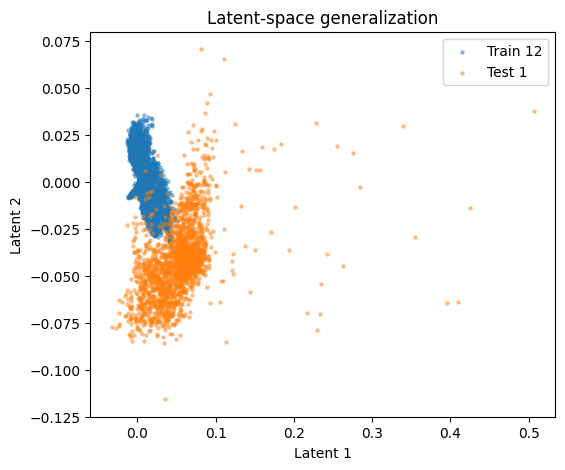

In [ ]:
z_train = z_train.cpu().numpy()
z_test = z_test.cpu().numpy()

plt.figure(figsize=(6, 5))
plt.scatter(z_train[:, 0], z_train[:, 1], s=5, alpha=0.4, label=f"Train {k}")
plt.scatter(z_test[:, 0], z_test[:, 1], s=5, alpha=0.4, label=f"Test {k_test}")
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.legend()
plt.title("Latent-space generalization")
plt.show()

- The VAE reconstructs spectra from the training dataset (k = 12) well. In the training examples for k = 12, the reconstructed spectra closely follow the original spectra, especially the main peak and broad plasmon feature. The training mean MSE is low, about 0.0009.

- However, the model performs poorly on the test dataset (k=1). The test spectra have different shapes, stronger noise, negative intensity regions and flat zero-like regions after interpolation or normalization. The reconstructed spectra do not follow these features well. Instead, the VAE produces spectra that look more like the training dataset. This gives a much larger test mean MSE of about 0.064.

- The latent-space plot also shows limited generalization. The training spectra form a compact cluster, while the test spectra are more widely spread and shifted away from the training cluster. This suggests that the VAE mainly learned dataset-specific features from dataset 12 rather than a fully general representation of ITO plasmon behavior across datasets.

## 6. Challenge: anomaly detection from VAE reconstruction error by Agnila

Use the trained VAE to search for unusual spectra in the ITO EELS maps (datasets). The idea is that spectra poorly reconstructed by the VAE may correspond to defects, contamination, edges, or measurement artifacts.

1) Reconstruct every spectrum in the spatial EELS map (dataset) using the trained VAE.
2) Compute the reconstruction loss (disparity between original and reconstructed spectra), for example the Mean Squared Error, for each pixel.
3) Visualize the reconstruction-error map.
4) Identify pixels or regions with unusually high reconstruction error.
5) Compare these regions with the original spectra and spatial location.

**Key question:** Can the VAE reconstruction error be used to detect defects, contamination, or measurement artifacts in the ITO cubes?

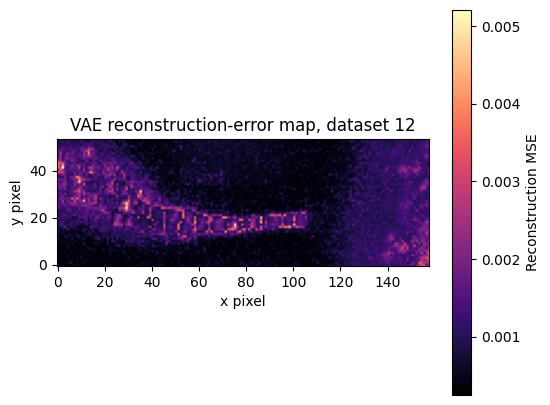

Mean MSE: 0.0009244106
Max MSE: 0.0052096616


In [ ]:
# 6. Anomaly detection from VAE reconstruction error

vae.eval()

with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    z, _ = vae.encode(X_tensor)
    X_rec = vae.decode(z).cpu().numpy()

# Reconstruction error for each pixel spectrum
pixel_mse = np.mean((X - X_rec) ** 2, axis=1)

# Reshape back into spatial map
error_map = pixel_mse.reshape(d1, d2)

plt.figure(figsize=(6, 5))
plt.imshow(error_map, origin="lower", cmap="magma")
plt.colorbar(label="Reconstruction MSE")
plt.title(f"VAE reconstruction-error map, dataset {k}")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.show()

print("Mean MSE:", pixel_mse.mean())
print("Max MSE:", pixel_mse.max())

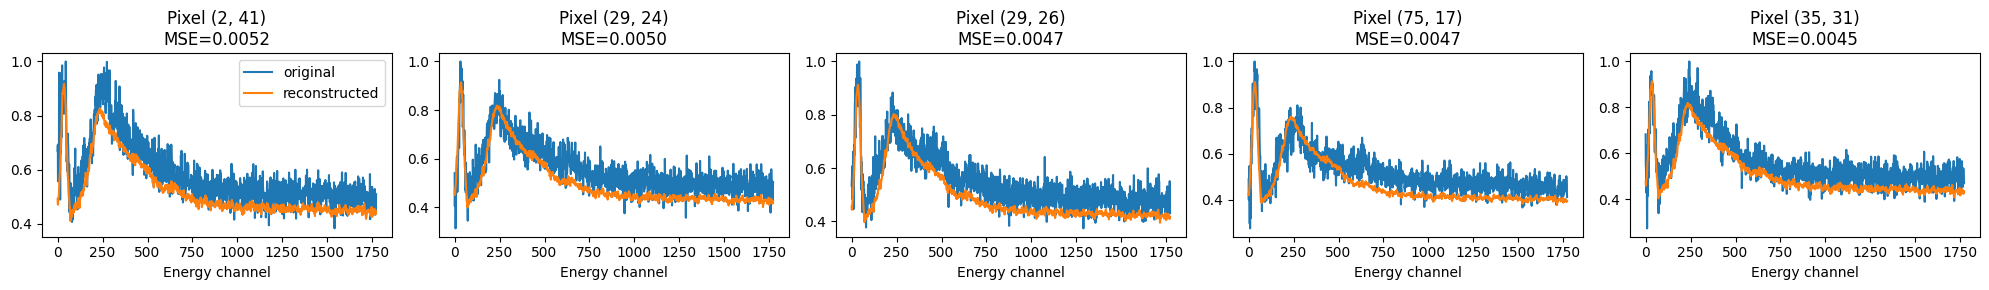

In [ ]:
# Find highest-error pixels
n_anomalies = 5
worst_idx = np.argsort(pixel_mse)[-n_anomalies:][::-1]

fig, axes = plt.subplots(1, n_anomalies, figsize=(4 * n_anomalies, 3))

for i, idx in enumerate(worst_idx):
    y, x = np.unravel_index(idx, (d1, d2))

    axes[i].plot(X[idx], label="original")
    axes[i].plot(X_rec[idx], label="reconstructed")
    axes[i].set_title(f"Pixel ({x}, {y})\nMSE={pixel_mse[idx]:.4f}")
    axes[i].set_xlabel("Energy channel")

axes[0].legend()
plt.tight_layout()
plt.show()

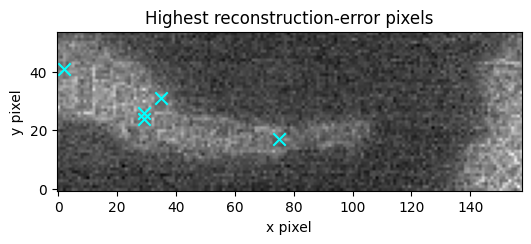

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(hdata[..., s], origin="lower", cmap="gray")

for idx in worst_idx:
    y, x = np.unravel_index(idx, (d1, d2))
    plt.scatter(x, y, c="cyan", marker="x", s=80)

plt.title("Highest reconstruction-error pixels")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.show()

- The VAE reconstruction-error map shows that most pixels have low reconstruction error, with a mean MSE of about 0.00092.
- A few localized regions show much higher error, with the maximum MSE around 0.0052. These high-error pixels appear near structural edges, brighter or irregular regions of the EELS map.
The spectra from the highest-error pixels are not completely random, but the VAE underestimates parts of the broad peak and smooths over some detailed intensity variations. This suggests that these spectra are less typical compared with the spectra learned by the VAE.

Therefore, the VAE reconstruction error can be used as an anomaly indicator. In this dataset, the highest-error regions may correspond to edge effects, local thickness/geometry changes, or measurement artifacts rather than the average ITO plasmon behavior.